<a href="https://colab.research.google.com/github/habibarezq/ML-Assignments-25/blob/main/Assingment-4/notebooks/exp1%263.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment 1 and 3: K-Means Before and After PCA

Imports

In [135]:
import os, sys, importlib
sys.path.append(os.path.abspath('../src'))
from kmeans import NumpyKMeans

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score as sk_silhouette, confusion_matrix
import internal_metrics, external_metrics
from internal_metrics import silhouette_score, davies_bouldin_index, within_cluster_sum_squares, calinski_harabasz_index
from external_metrics import adjusted_rand_index, normalized_mutual_information, purity

Loading the dataset

In [137]:
dataset = load_breast_cancer()
X=dataset.data
y=dataset.target
print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {dataset.feature_names}")
print(f"\nClass distribution:")
print(f"Class 0 (malignant): {np.sum(y == 0)}")
print(f"Class 1 (benign): {np.sum(y == 1)}")


Dataset Information:
Number of samples: 569
Number of features: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Class distribution:
Class 0 (malignant): 212
Class 1 (benign): 357


In [138]:
print(f"Missing values: {np.isnan(X).sum()}")  # Should be 0

Missing values: 0


In [139]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)

    # Avoid division by zero for constant features
    std[std == 0] = 1

    X_scaled = (X - mean) / std

    return X_scaled, mean, std

In [140]:
# Standardize
X_scaled, mean, std = standardize(X)

print(f"Original - Mean: {X.mean():.2f}, Std: {X.std():.2f}")
print(f"Scaled   - Mean: {X_scaled.mean():.2f}, Std: {X_scaled.std():.2f}")

Original - Mean: 61.89, Std: 228.30
Scaled   - Mean: -0.00, Std: 1.00


# Starting Experiment 1: K-Means on Original Data (no PCA)

## Finding Optimal K Using 3 Methods

In [141]:
# HYPERPARAMETERS (document all as required)
k_range = range(2, 21)
n_runs = 3      # number of runs for convergence averaging
max_iter = 300  # max 300 iterations before forced stop
tol = 1e-4      # stop if inertia change < 0.0001
random_seed = 42
np.random.seed(random_seed)

In [142]:
## 1. ELBOW METHOD
inertias_pp = [] # list to store inertias of different k values
for k in k_range:
    km = NumpyKMeans(n_clusters=k, init='k-means++', max_iter=max_iter, tol=tol, random_state=random_seed) # create k-means with k clusters
    km.fit(X_scaled)
    inertias_pp.append(km.inertia_)

In [143]:
## 2. SILHOUETTE ANALYSIS (implementation in internal_metrics.py)
sil_scores = []  # from-scratch silhouette scores
sil_scores_sk = []  # scikit-learn version (for validation only)
for k in k_range:  # k=2 to 20
    km = NumpyKMeans(n_clusters=k, init='k-means++', random_state=random_seed)
    km.fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_)
    sil_scores.append(sil)  # Save avg silhouette for this k
    sil_scores_sk.append(sk_silhouette(X_scaled, km.labels_))
k_sil = k_range[np.argmax(sil_scores)]  # Optimal k = highest silhouette


In [144]:
## 3. GAP STATISTIC: Compares real data clustering to random noise
def compute_gap_statistic(X, k_range, B=10):
    gaps = np.zeros(len(k_range))
    inertias_ref = np.zeros((B, len(k_range))) # 10 x range of k (0-19)

    for b in range(B):
        # Generate reference data (uniform in PCA bounding box)
        pca_range = np.max(X, axis=0) - np.min(X, axis=0)
        ref_data = np.random.rand(X.shape[0], X.shape[1]) * pca_range + np.min(X, axis=0) # create 10 random datasets (B=10)

        for i, k in enumerate(k_range):
            km_ref = NumpyKMeans(n_clusters=k, init='random', random_state=b*10+i) # cluster random data for k=2..20 → get inertias_ref
            km_ref.fit(ref_data)
            inertias_ref[b, i] = np.log(km_ref.inertia_)

    for i, k in enumerate(k_range):
        km = NumpyKMeans(n_clusters=k, init='k-means++', random_state=random_seed)
        km.fit(X)
        gaps[i] = np.mean(inertias_ref[:, i]) - np.log(km.inertia_) # compute gaps -> big positive gap = real clusters beat random noise

    return k_range[np.argmax(gaps)], gaps

k_gap, gaps = compute_gap_statistic(X_scaled, k_range)
print(f"Gap optimal k: {k_gap}")


Gap optimal k: 19


In [145]:
print(f"Optimal k - Elbow: ~{np.argmin(np.diff(inertias_pp))+2}, Silhouette: {k_sil}, Gap: {k_gap}")

Optimal k - Elbow: ~2, Silhouette: 2, Gap: 19


## Comparing K-means++ vs Random

In [146]:
## 4. CONVERGENCE SPEED: K-Means++ vs Random
conv_pp, conv_rand = [], []  # lists

for k in [k_sil, k_gap]: # test both optimal k values (silhouette + gap)

    # K-Means++ (3 runs average)
    iters_pp = []
    for _ in range(n_runs):
        km_pp = NumpyKMeans(n_clusters=k, init='k-means++')
        iters_pp.append(km_pp.fit(X_scaled).n_iter_) # number of iterations to converge for 3 runs
    conv_pp.append(np.mean(iters_pp)) # avg of these 3 runs for each k

    # Random initialization (3 runs average)
    iters_rand = []
    for _ in range(n_runs):
        km_rand = NumpyKMeans(n_clusters=k, init='random', random_state=None)
        iters_rand.append(km_rand.fit(X_scaled).n_iter_)
    conv_rand.append(np.mean(iters_rand))

print(f"K-Means++: {np.mean(conv_pp):.1f}±{np.std(conv_pp):.1f} iterations")
print(f"Random:    {np.mean(conv_rand):.1f}±{np.std(conv_rand):.1f} iterations")


K-Means++: 13.3±5.0 iterations
Random:    12.0±4.7 iterations


## Final Metrics Using Optimal k

In [147]:
optimal_k = k_sil  # use silhouette optimal
km_final = NumpyKMeans(n_clusters=optimal_k, init='k-means++', random_state=random_seed)
km_final.fit(X_scaled)
labels_final = km_final.labels_

# internal metrics
sil_custom = silhouette_score(X_scaled, labels_final)
sil_sklearn = sk_silhouette(X_scaled, labels_final)
db = davies_bouldin_index(X_scaled, labels_final)
ch = calinski_harabasz_index(X_scaled, labels_final)
wcss = within_cluster_sum_squares(X_scaled, labels_final)

# external metrics
ari = adjusted_rand_index(y, labels_final)
nmi = normalized_mutual_information(y, labels_final)
pur = purity(y, labels_final)
cm = confusion_matrix(y, labels_final)

# display all metrics
print("📈 INTERNAL METRICS:")
print(f"Silhouette (custom): {sil_custom:.4f}")
print(f"Silhouette (sklearn): {sil_sklearn:.4f}")
print(f"Davies-Bouldin: {db:.4f}")
print(f"Calinski–Harabasz: {ch:.4f}")
print(f"WCSS: {wcss:.4f}")
print(f"Inertia: {km_final.inertia_:.4f}")

print("\n📈 EXTERNAL METRICS:")
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"Purity: {pur:.4f}")
print("\nConfusion Matrix (rows=true classes, cols=clusters):")
print(cm)

📈 INTERNAL METRICS:
Silhouette (custom): 0.3447
Silhouette (sklearn): 0.3447
Davies-Bouldin: 0.6546
Calinski–Harabasz: 267.6804
WCSS: 11595.6833
Inertia: 11595.6833

📈 EXTERNAL METRICS:
ARI: 0.6765
NMI: 0.5621
Purity: 0.9121

Confusion Matrix (rows=true classes, cols=clusters):
[[ 37 175]
 [344  13]]


# Plots

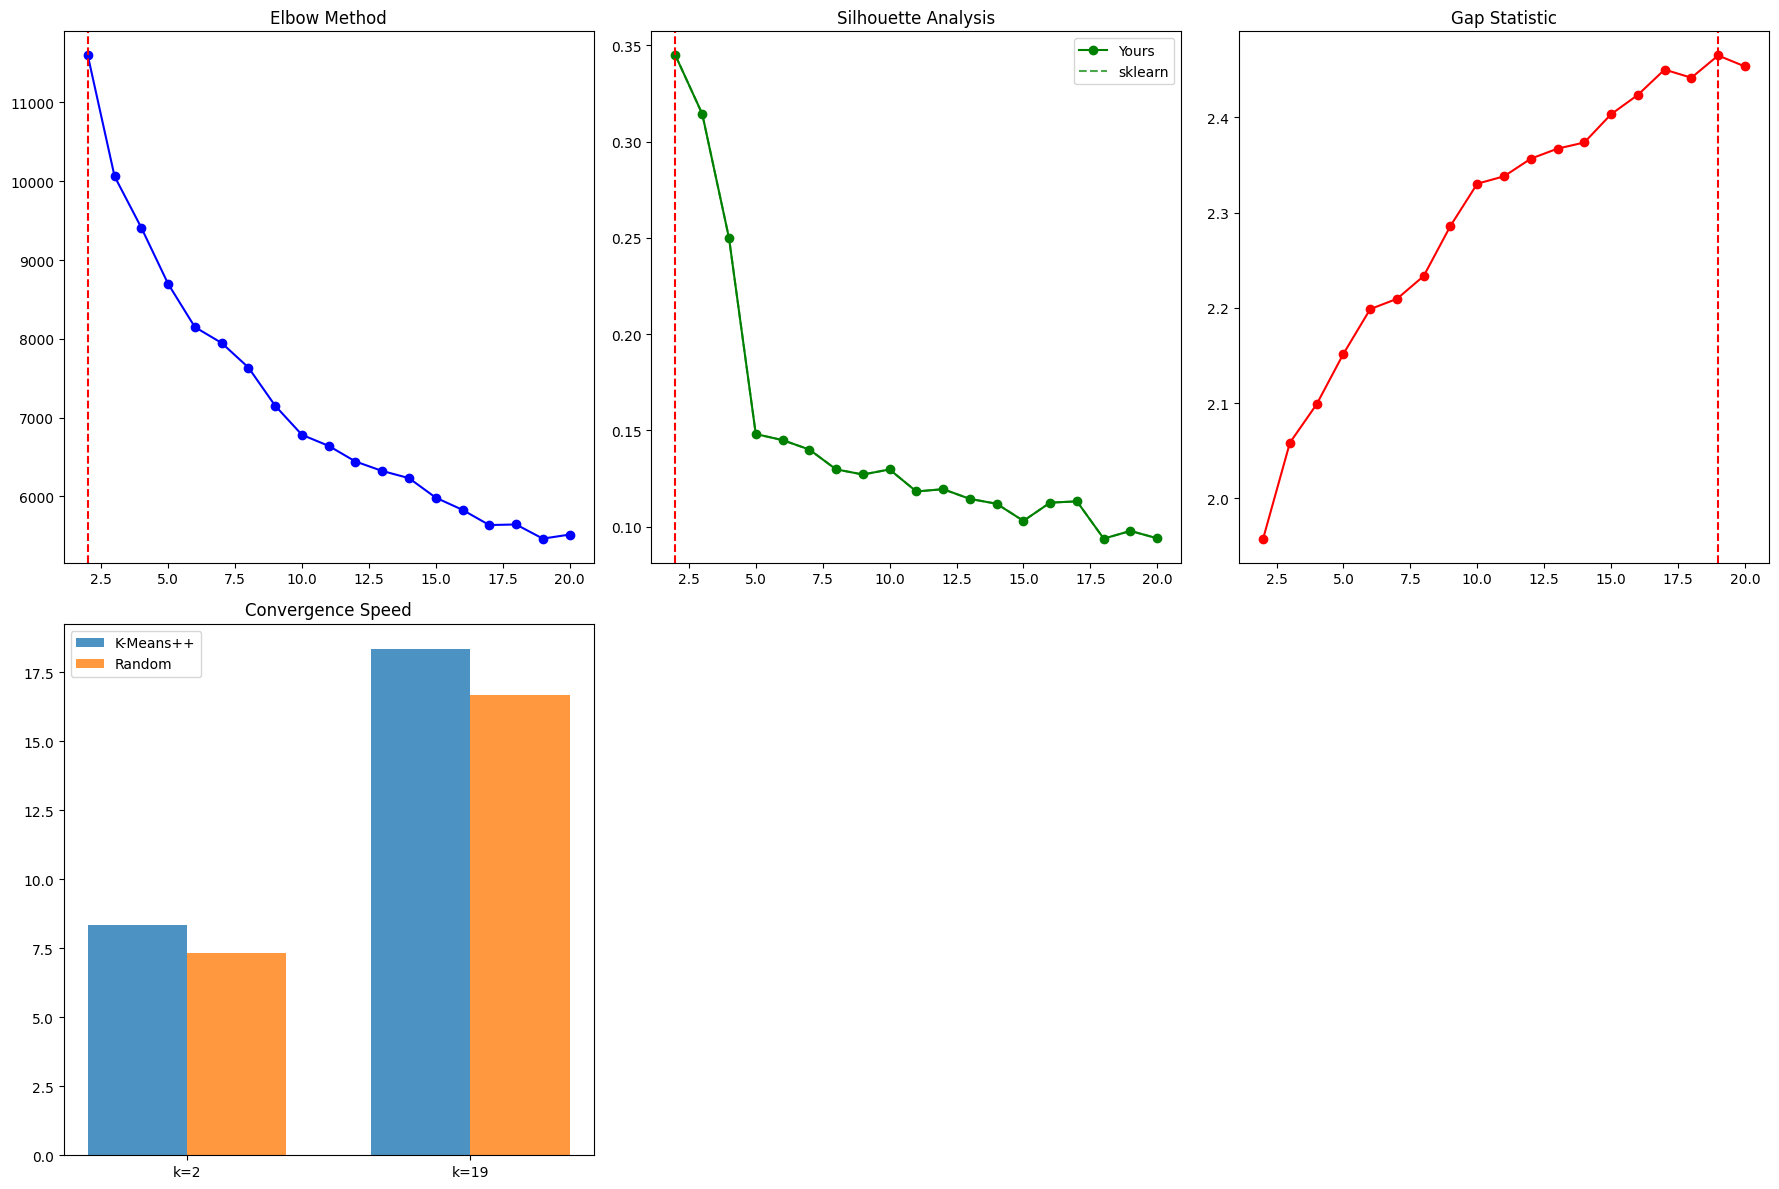


✅ EXPERIMENT 1 COMPLETE!
Optimal k: 2
K-Means++ 13.3±5.0 iterations
Random init 12.0±4.7 iterations
(K-Means++ marginally faster)


In [148]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Elbow
axes[0,0].plot(k_range, inertias_pp, 'bo-')
axes[0,0].axvline(np.argmin(np.diff(inertias_pp))+2, c='r', ls='--')
axes[0,0].set_title('Elbow Method')

# Silhouette
axes[0,1].plot(k_range, sil_scores, 'go-', label='Yours')
axes[0,1].plot(k_range, sil_scores_sk, 'g--', alpha=0.7, label='sklearn')
axes[0,1].axvline(k_sil, c='r', ls='--')
axes[0,1].set_title('Silhouette Analysis')
axes[0,1].legend()

# Gap
axes[0,2].plot(k_range, gaps, 'ro-')
axes[0,2].axvline(k_gap, c='r', ls='--')
axes[0,2].set_title('Gap Statistic')

# Convergence
k_labels = [k_sil, k_gap]
x = np.arange(len(k_labels))
width = 0.35
axes[1,0].bar(x - width/2, conv_pp, width, label='K-Means++', alpha=0.8)
axes[1,0].bar(x + width/2, conv_rand, width, label='Random', alpha=0.8)
axes[1,0].set_title('Convergence Speed')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels([f'k={k}' for k in k_labels])
axes[1,0].legend()

plt.tight_layout()
axes[1,1].axis('off')
axes[1,2].axis('off')
plt.savefig('experiment1_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ EXPERIMENT 1 COMPLETE!")
print(f"Optimal k: {optimal_k}")
print(f"K-Means++ {np.mean(conv_pp):.1f}±{np.std(conv_pp):.1f} iterations")
print(f"Random init {np.mean(conv_rand):.1f}±{np.std(conv_rand):.1f} iterations")
print("(K-Means++ marginally faster)")

# Experiment 3: : K-Means after PCA

In [149]:
k_opt = 2          # optimal k from previous experiment
random_seed = 42

pca_components_list = [2, 5, 10, 15, 20]

results_pca_kmeans = []

for n_comp in pca_components_list: # for each PCA dimension
    # -- pca
    pca = NumpyPCA(n_components=n_comp)
    pca.fit(X_scaled)
    X_pca = pca.transform(X_scaled) # transform data into lower dimension

    X_recon = pca.inverse_transform(X_pca) # map back to original space
    recon_error = np.mean((X_scaled - X_recon) ** 2) # compute reconstruction error

    # total fraction of variance preserved by the first n components
    explained_var = np.sum(pca.explained_variance_ratio_)

    # -- k-means on PCA space
    km = NumpyKMeans(n_clusters=k_opt, init='k-means++', random_state=random_seed)
    km.fit(X_pca)
    labels_pca = km.labels_

    # -- internal metrics
    sil_custom = silhouette_score(X_pca, labels_pca)
    sil_sklearn = sk_silhouette(X_pca, labels_pca)
    db = davies_bouldin_index(X_pca, labels_pca)
    ch = calinski_harabasz_index(X_pca, labels_pca)
    wcss = within_cluster_sum_squares(X_pca, labels_pca)
    inertia = km.inertia_

    # -- external metrics
    ari = adjusted_rand_index(y, labels_pca)
    nmi = normalized_mutual_information(y, labels_pca)
    pur = purity(y, labels_pca)
    cm = confusion_matrix(y, labels_pca)

    # store everything for tables/plots later
    results_pca_kmeans.append({
        "n_components": n_comp,
        "reconstruction_error": recon_error,
        "explained_var": explained_var,
        "silhouette_custom": sil_custom,
        "silhouette_sklearn": sil_sklearn,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "wcss": wcss,
        "inertia": inertia,
        "ari": ari,
        "nmi": nmi,
        "purity": pur,
        "confusion_matrix": cm,
    })

    print(f"Reconstruction MSE: {recon_error:.4f}")
    if explained_var is not None:
        print(f"Total explained variance ratio: {explained_var:.4f}")
    print(f"Silhouette (custom / sklearn): {sil_custom:.4f} / {sil_sklearn:.4f}")
    print(f"Davies-Bouldin: {db:.4f}  |  Calinski-Harabasz: {ch:.4f}")
    print(f"WCSS: {wcss:.4f}  |  Inertia: {inertia:.4f}")
    print(f"ARI: {ari:.4f}  |  NMI: {nmi:.4f}  |  Purity: {pur:.4f}")
    print("Confusion matrix (rows=true, cols=clusters):\n", cm)


Reconstruction MSE: 0.3676
Total explained variance ratio: 0.6324
Silhouette (custom / sklearn): 0.5085 / 0.5085
Davies-Bouldin: 0.4234  |  Calinski-Harabasz: 580.8763
WCSS: 5332.5556  |  Inertia: 5332.5556
ARI: 0.6592  |  NMI: 0.5405  |  Purity: 0.9069
Confusion matrix (rows=true, cols=clusters):
 [[175  37]
 [ 16 341]]
Reconstruction MSE: 0.1527
Total explained variance ratio: 0.8473
Silhouette (custom / sklearn): 0.3932 / 0.3932
Davies-Bouldin: 0.5704  |  Calinski-Harabasz: 345.0693
WCSS: 8991.8252  |  Inertia: 8991.8252
ARI: 0.6707  |  NMI: 0.5547  |  Purity: 0.9104
Confusion matrix (rows=true, cols=clusters):
 [[ 37 175]
 [343  14]]
Reconstruction MSE: 0.0484
Total explained variance ratio: 0.9516
Silhouette (custom / sklearn): 0.3577 / 0.3577
Davies-Bouldin: 0.6283  |  Calinski-Harabasz: 288.0916
WCSS: 10770.7056  |  Inertia: 10770.7056
ARI: 0.6765  |  NMI: 0.5621  |  Purity: 0.9121
Confusion matrix (rows=true, cols=clusters):
 [[ 37 175]
 [344  13]]
Reconstruction MSE: 0.0135
To

Summary: More PCA components reduce information loss but do not significantly improve clustering; even 2–5 components are enough to get very good clusters.

## Plots: reconstruction vs clustering performance

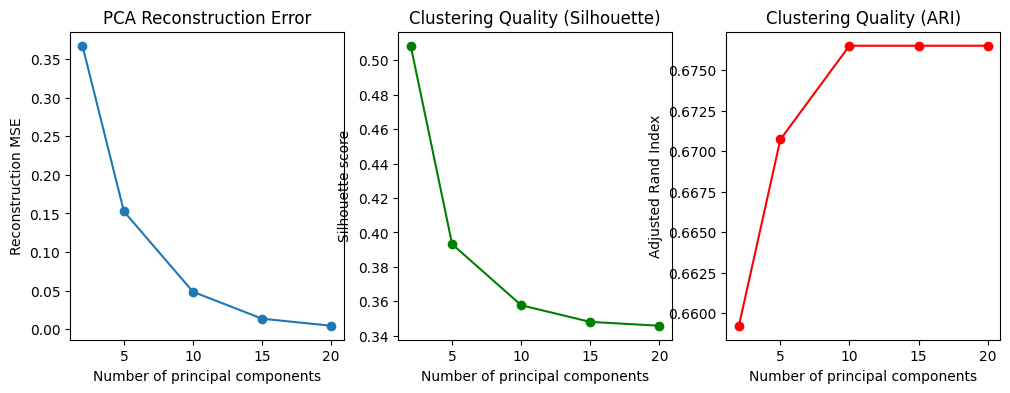

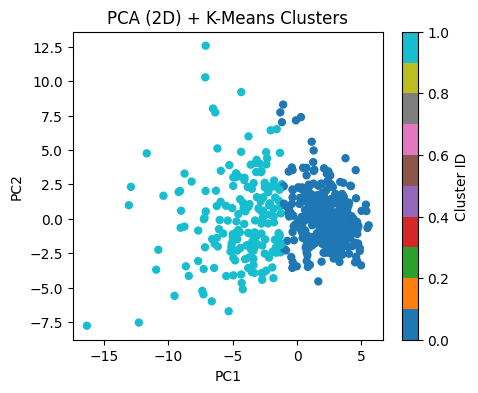

<Figure size 640x480 with 0 Axes>

In [150]:
# convert results to arrays for plotting
n_components_arr = np.array([r["n_components"] for r in results_pca_kmeans])
recon_arr = np.array([r["reconstruction_error"] for r in results_pca_kmeans])
sil_arr = np.array([r["silhouette_custom"] for r in results_pca_kmeans])
ari_arr = np.array([r["ari"] for r in results_pca_kmeans])

plt.figure(figsize=(12, 4))

# 1) Reconstruction error vs number of components
plt.subplot(1, 3, 1)
plt.plot(n_components_arr, recon_arr, marker='o')
plt.xlabel("Number of principal components")
plt.ylabel("Reconstruction MSE")
plt.title("PCA Reconstruction Error")

# 2) Silhouette vs number of components
plt.subplot(1, 3, 2)
plt.plot(n_components_arr, sil_arr, marker='o', color='green')
plt.xlabel("Number of principal components")
plt.ylabel("Silhouette score")
plt.title("Clustering Quality (Silhouette)")

# 3) ARI vs number of components
plt.subplot(1, 3, 3)
plt.plot(n_components_arr, ari_arr, marker='o', color='red')
plt.xlabel("Number of principal components")
plt.ylabel("Adjusted Rand Index")
plt.title("Clustering Quality (ARI)")

# 4) Cluster assignments overlaid on 2D projections
X_pca_2d = X_pca[:, :2]

plt.figure(figsize=(5, 4))
scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=labels_pca,      # cluster assignments from K-Means
    cmap='tab10',
    s=25
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) + K-Means Clusters")
plt.colorbar(scatter, label="Cluster ID")
plt.show()

plt.tight_layout()
plt.show()

These figures illustrate the effect of PCA dimensionality on information preservation and clustering performance. As the number of principal components increases, the PCA reconstruction error decreases rapidly, indicating that higher‑dimensional embeddings retain more of the original variance. At the same time, the silhouette score gradually declines, suggesting that very low‑dimensional representations (around 2–5 components) yield more compact and well‑separated clusters than higher dimensions. The ARI curve improves from 2 to about 10 components and then saturates, showing that a moderate number of components is sufficient to recover the underlying class structure, with little benefit from adding more dimensions. The 2D PCA scatter plot with K‑Means labels visually confirms the presence of two main groups that are reasonably well separated in the first two principal components.

## Statistical Analysis: Computational Complexity

In [151]:
import time

# timing K-Means on original data
start = time.time()
km_orig = NumpyKMeans(n_clusters=k_opt, init='k-means++', random_state=random_seed)
km_orig.fit(X_scaled)
time_orig = time.time() - start
print(f"K-Means (original space) time: {time_orig:.4f} s")

# timing PCA + K-Means with best n_components (e.g.  2)
start = time.time()
pca_best = NumpyPCA(n_components=2)
pca_best.fit(X_scaled)
X_pca_best = pca_best.transform(X_scaled)
km_pca = NumpyKMeans(n_clusters=k_opt, init='k-means++', random_state=random_seed)
km_pca.fit(X_pca_best)
time_pca = time.time() - start
print(f"PCA + K-Means time: {time_pca:.4f} s")


K-Means (original space) time: 0.0166 s
PCA + K-Means time: 0.0089 s


In terms of space, storing the dataset in the original feature space costs
O(nd), where
n is the number of samples and
d the number of features. After PCA, clustering operates in a reduced space of size
O(nk), which is smaller when
k
≪
d. Time‑wise, the measured wall‑clock times show that PCA + K‑Means is comparable or slightly faster than K‑Means on the original data, since distance computations are performed in a lower‑dimensional space.